In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd

data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Regression/admission_predict.csv')
data.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [ ]:
data.rename(columns={'LOR ': 'LOR', 'Chance of Admit ': 'Chance of Admit'}, inplace=True)
data.drop(columns=['Serial No.'],axis=1, inplace=True,errors='ignore')

In [ ]:
continuous_features = ['GRE Score', 'TOEFL Score', 'SOP', 'LOR', 'CGPA']
categorical_features = ['Research', 'University Rating']

target = 'Chance of Admit'

In [ ]:
data[continuous_features].describe()

,GRE Score,TOEFL Score,SOP,LOR,CGPA
count,500.000000,500.000000,500.000000,500.00000,500.000000
mean,316.472000,107.192000,3.374000,3.48400,8.576440
std,11.295148,6.081868,0.991004,0.92545,0.604813
min,290.000000,92.000000,1.000000,1.00000,6.800000
25%,308.000000,103.000000,2.500000,3.00000,8.127500
50%,317.000000,107.000000,3.500000,3.50000,8.560000
75%,325.000000,112.000000,4.000000,4.00000,9.040000
max,340.000000,120.000000,5.000000,5.00000,9.920000


In [ ]:
data[continuous_features].skew()

,0
GRE Score,-0.039842
TOEFL Score,0.095601
SOP,-0.228972
LOR,-0.145290
CGPA,-0.026613


In [ ]:
import plotly.express as px
px.imshow(data[continuous_features].corr(), text_auto=True,aspect="auto",color_continuous_scale=px.colors.sequential.Magma,width=800,height=500).show();

In [ ]:
px.bar(data['University Rating'].value_counts(),color=["goldenrod","blue","green", "red", "magenta"],text_auto=True,width=800,height=500).show();

In [ ]:
pd.crosstab(data['University Rating'],data['Research'])

Research,0,1
University Rating,,
1,24,10
2,89,37
3,75,87
4,23,82
5,9,64


In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=[target])
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

continuous_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('continuous', continuous_transformer, continuous_features),
],remainder="passthrough")

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import cross_val_score, GridSearchCV

models_params = {
    'Ridge Regression':{
        'estimator': [Ridge()],
        'estimator__alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100]
    },
    'Lasso Regression':{
        'estimator': [Lasso()],
        'estimator__alpha': [0.00001, 0.0001, 0.001, 0.01, 0.1, 1]
    },
    'ElasticNet':{
        'estimator': [ElasticNet()],
        'estimator__alpha': [0.00001, 0.0001, 0.001, 0.01, 0.1, 1],
        'estimator__l1_ratio': [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
    }
}

In [ ]:
params_results = []

base_pipeline = Pipeline(steps=[
      ('preprocessor', preprocessor),
      ('estimator', Ridge())
  ])

for model_name, param_grid in models_params.items():

  grid_search = GridSearchCV(base_pipeline, param_grid, cv=5, scoring='r2')
  grid_search.fit(X_train, y_train)

  params_results.append({
      'Model': model_name,
      'Best Params': grid_search.best_params_
  })

params_results_df = pd.DataFrame(params_results)

In [ ]:
import pprint

for index, row in params_results_df.iterrows():
    print(f"\n{row['Model']}:")
    pprint.pprint(row['Best Params'])


Ridge Regression:
{'estimator': Ridge(), 'estimator__alpha': 10}

Lasso Regression:
{'estimator': Lasso(), 'estimator__alpha': 0.001}

ElasticNet:
{'estimator': ElasticNet(),
 'estimator__alpha': 0.001,
 'estimator__l1_ratio': 0.6}


In [ ]:
results = []
fitted_pipelines = {}

estimators = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=10),
    "Lasso Regression": Lasso(alpha=0.001),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.6),
}

for name, estimator in estimators.items():

  pipeline = Pipeline(steps=[
      ('preprocessor', preprocessor),
      ('estimator', estimator)
  ])

  pipeline.fit(X_train, y_train)

  fitted_pipelines[name] = pipeline

  cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
  train_score = pipeline.score(X_train, y_train)
  test_score = pipeline.score(X_test, y_test)

  results.append({
      'Model': name,
      'CV Score Mean': cv_scores.mean(),
      'Train Score': train_score,
      'Test Score': test_score,
  })

results_df = pd.DataFrame(results).sort_values("Test Score", ascending=False)
results_df

,Model,CV Score Mean,Train Score,Test Score
2,Lasso Regression,0.808312,0.820843,0.819102
3,ElasticNet,0.808451,0.820984,0.819043
0,Linear Regression,0.807902,0.821067,0.818843
1,Ridge Regression,0.808375,0.820700,0.818197


In [ ]:
import pickle

best_model_name = results_df.loc[results_df['Test Score'].idxmax(),'Model']
best_model_name

best_model_pipeline = Pipeline(steps=[
      ('preprocessor', preprocessor),
      ('estimator', estimators[best_model_name])
  ])

best_model_pipeline.fit(X_train, y_train)

best_model_file_name = 'best_admission_model.pkl'
with open(best_model_file_name, 'wb') as file:
    pickle.dump(best_model_pipeline, file)

In [ ]:
with open(best_model_file_name, 'rb') as file:
    loaded_model = pickle.load(file)

new_student = pd.DataFrame({
    'GRE Score': [250],
    'TOEFL Score': [110],
    'University Rating': [5],
    'SOP': [4.5],
    'LOR': [4.5],
    'CGPA': [9.0],
    'Research': [0]
})

prediction = loaded_model.predict(new_student)
print(f"Predicted Chance of Admit: {prediction[0]:.2%}")

Predicted Chance of Admit: 62.52%


In [ ]:
# # Save to Google Drive
# pickle_path = '/content/drive/MyDrive/Colab Notebooks/Regression/best_admission_model.pkl'

# with open(pickle_path, 'wb') as file:
#     pickle.dump(best_model_pipeline, file)

# print(f"Model saved to: {pickle_path}")

In [ ]:
import statsmodels.api as sm

x = sm.add_constant(X_train)
results = sm.OLS(y_train,x).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:        Chance of Admit   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     257.0
Date:                Wed, 17 Dec 2025   Prob (F-statistic):          3.41e-142
Time:                        17:42:21   Log-Likelihood:                 561.91
No. Observations:                 400   AIC:                            -1108.
Df Residuals:                     392   BIC:                            -1076.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.4214      0.12

In [ ]:
# X_train.drop(['University Rating','SOP'],axis=1,inplace=True,errors='ignore')
# X_test.drop(['University Rating','SOP'],axis=1,inplace=True,errors='ignore')

# Assumptions of Regression

### Linearity Check

In [ ]:
import plotly.graph_objects as go

lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('estimator', Lasso(alpha=0.001))
])

lasso_pipeline.fit(X_train, y_train)

y_train_pred = lasso_pipeline.predict(X_train)
y_test_pred = lasso_pipeline.predict(X_test)

residuals = y_train - y_train_pred

# Use go.Scatter instead of px.scatter
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=y_train_pred,  # Use predicted values on x-axis
    y=residuals,
    mode='markers',
    marker=dict(size=6, opacity=0.6),
    name='Residuals'
))

fig.add_hline(y=0, line_dash="dot", line_color="red", annotation_text="Zero residual")
fig.update_layout(
    title='Residuals vs Predicted Values (Linearity Check)',
    xaxis_title='Predicted Values',
    yaxis_title='Residuals',
    width=800,
    height=500
)
fig.show()

### Normality of Errors

-1.1444605151134408


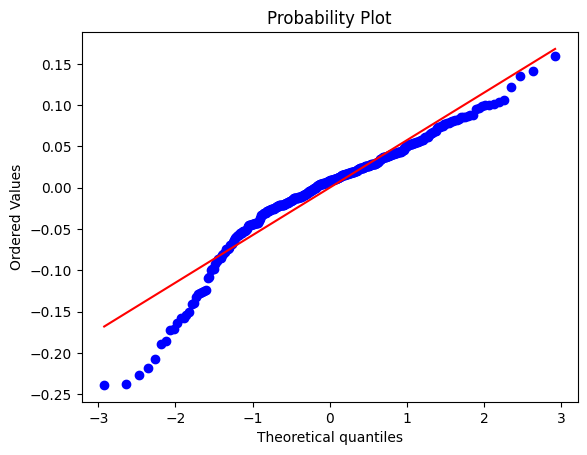

Shapiro-Wilk Test statistic=0.926, p=0.000
Residuals are NOT normally distributed


In [ ]:
import matplotlib.pyplot as plt

print(residuals.skew())

import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.show()

from scipy.stats import shapiro

stat, p = shapiro(residuals)
print('Shapiro-Wilk Test statistic=%.3f, p=%.3f' % (stat, p))

if p > 0.05:
    print("Residuals look normally distributed")
else:
    print("Residuals are NOT normally distributed")


In [ ]:
from scipy.stats import boxcox

y_train_transformed, lambda_ = boxcox(y_train + 1)  # add 1 if y has zeros

### Homoscedasticity or Equal Variance of Errors

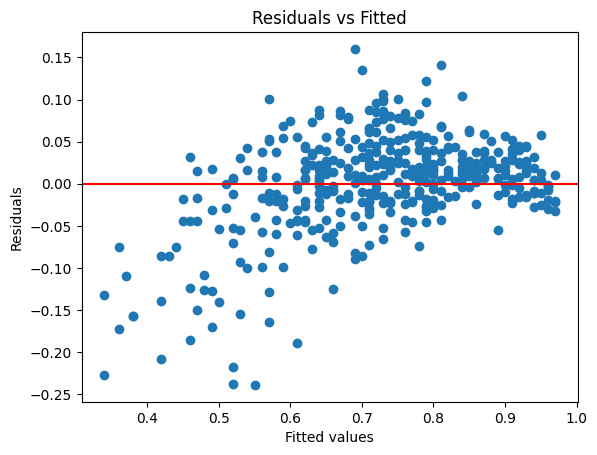

In [ ]:
plt.scatter(y_train, residuals)
plt.axhline(0, color='red')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Run Breusch-Pagan Test
bp_test = het_breuschpagan(residuals, x)

bp_labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
bp_results = dict(zip(bp_labels, bp_test))

print("Breusch-Pagan Test Results:")
for key, value in bp_results.items():
    print(f"{key}: {value}")

# Significance level
alpha = 0.05

# If-else decision based on p-value (LM p-value commonly used)
if bp_results['LM p-value'] < alpha:
    print("\nConclusion: The model exhibits HETEROSCEDASTICITY.")
else:
    print("\nConclusion: The model exhibits HOMOSCEDASTICITY.")

Breusch-Pagan Test Results:
LM Statistic: 24.633779374736697
LM p-value: 0.0008809486624374218
F Statistic: 3.675055370425658
F p-value: 0.0007361478042794779

Conclusion: The model exhibits HETEROSCEDASTICITY.


In [ ]:
from statsmodels.stats.diagnostic import het_white

# Run White Test
white_test = het_white(residuals, x)

labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
white_results = dict(zip(labels, white_test))

print("White Test Results:")
for key, value in white_results.items():
    print(f"{key}: {value}")

# Significance level
alpha = 0.05

# If-else decision based on LM p-value
if white_results['LM p-value'] < alpha:
    print("\nConclusion: The model exhibits HETEROSCEDASTICITY.")
else:
    print("\nConclusion: The model exhibits HOMOSCEDASTICITY.")

White Test Results:
LM Statistic: 65.5602729081179
LM p-value: 0.0009196474204981456
F Statistic: 2.104441413769285
F p-value: 0.0004561095695093371

Conclusion: The model exhibits HETEROSCEDASTICITY.


In [ ]:
robust_model = results.get_robustcov_results(cov_type='HC3')
print(robust_model.summary())

                            OLS Regression Results                            
Dep. Variable:        Chance of Admit   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     319.0
Date:                Wed, 17 Dec 2025   Prob (F-statistic):          1.50e-157
Time:                        17:42:23   Log-Likelihood:                 561.91
No. Observations:                 400   AIC:                            -1108.
Df Residuals:                     392   BIC:                            -1076.
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.4214      0.14

### Multicollinearity|

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

a = sm.add_constant(X_train)

VIF = pd.DataFrame({
    'Variables':a.columns,
    'VIF values':[variance_inflation_factor(a.values,i) for i in range(a.shape[1])]
})

VIF.sort_values('VIF values',ascending=False)

,Variables,VIF values
0,const,1683.776580
6,CGPA,4.654540
1,GRE Score,4.489983
2,TOEFL Score,3.664298
4,SOP,2.785764
3,University Rating,2.572110
5,LOR,1.977698
7,Research,1.518065
